# 01 — Explore Biomedical NER Datasets (JNLPBA & BC5CDR)

This notebook is for inspect the datasets for fine‑tune BioBERT.

- Load **JNLPBA** (genes/proteins) and **BC5CDR** (chemicals/diseases)
- Map label IDs → names
- Check label distribution and sequence lengths
- Peek at a few annotated examples


In [1]:
# If running in Colab, uncomment the next line to ensure required libraries are present
# !pip -q install datasets>=2.19

from datasets import load_dataset
from collections import Counter
import itertools
from statistics import median

def load_ds(name: str):
    ds = load_dataset(name)
    labels = ds["train"].features["ner_tags"].feature.names
    id2label = {i: n for i, n in enumerate(labels)}
    label2id = {n: i for i, n in enumerate(labels)}
    return ds, labels, id2label, label2id

print("Ready.")

/opt/anaconda3/envs/biobert_biomarker_ner/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
print("Parent dir added:", os.path.abspath(".."))


Parent dir added: /Users/yijin/Document/biobert_biomarker_ner


Parent dir added: ~/biobert_biomarker_ner

In [3]:
# list file in the parent directory
root = os.path.abspath("..")
print("Project root:", root)
print("Contents:", os.listdir(root))


Project root: /Users/yijin/Document/biobert_biomarker_ner
Contents: ['demo', '.DS_Store', 'requirements.txt', 'env.yaml', 'README.md', 'configs', 'notebooks', '.idea', 'src']


Project root: ~/biobert_biomarker_ner
Contents: ['demo', '.DS_Store', 'requirements.txt', 'README.md', 'configs', '.venv', 'notebooks', '.idea', 'src']

## 1) Load JNLPBA and inspect a sample

In [4]:
!pip install bioc
## BioC format for train/finetune model for biomedical text mining 
## ref: https://www.ncbi.nlm.nih.gov/research/bionlp/APIs/BioC-PubMed/

In [13]:
from transformers import AutoTokenizer
from src.data import load_ner_dataset, tokenize_and_align_labels

# Pick dataset + model tokenizer
DATASET = "bc5cdr"   # or "jnlpba"
MODEL = "dmis-lab/biobert-base-cased-v1.1"

# Step 1: Load dataset with BIO labels
ds, text_col, label_col, labels = load_ner_dataset(DATASET, tokenizer_name=MODEL)

print("Dataset splits:", ds)
print("Label set:", labels)
print("Text column:", text_col, "Label column:", label_col)



Dataset splits: DatasetDict({
    train: Dataset({
        features: ['id', 'document_id', 'passages', 'entities', 'events', 'coreferences', 'relations', 'tokens', 'ner_tags_str', 'ner_tags'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'document_id', 'passages', 'entities', 'events', 'coreferences', 'relations', 'tokens', 'ner_tags_str', 'ner_tags'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['id', 'document_id', 'passages', 'entities', 'events', 'coreferences', 'relations', 'tokens', 'ner_tags_str', 'ner_tags'],
        num_rows: 500
    })
})
Label set: ['B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease', 'O']
Text column: tokens Label column: ner_tags


In [14]:
# Step 2: Inspect one training example
ex = ds["train"][0]
print("\n--- Raw Example ---")
print("Tokens:", ex[text_col][:20])   # first 20 tokens
print("NER tags:", [labels[i] for i in ex[label_col][:20]])




--- Raw Example ---
Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine.', 'In', 'unanesthetized,', 'spontaneously', 'hypertensive', 'rats', 'the', 'decrease', 'in', 'blood', 'pressure', 'and', 'heart', 'rate']
NER tags: ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [15]:
# Step 3: Tokenize + align labels
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tok_ds = tokenize_and_align_labels(ds, tokenizer, text_col, label_col, max_length=128)

print("\n--- After Tokenization ---")
tok_ex = tok_ds["train"][0]
print("Input IDs:", tok_ex["input_ids"][:30])
print("Tokens:", tokenizer.convert_ids_to_tokens(tok_ex["input_ids"][:30]))
print("Labels:", tok_ex["labels"][:30])
print("Label Names:", [labels[i] if i != -100 else "PAD" for i in tok_ex["labels"][:30]])
               # int ids


Map: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 3066.15 examples/s]


--- After Tokenization ---
Input IDs: [101, 9468, 2858, 21501, 1162, 7936, 1116, 1103, 2848, 7889, 17786, 5026, 2109, 2629, 1104, 172, 4934, 2386, 2042, 119, 1107, 8362, 6354, 2050, 4638, 26300, 117, 20061, 1193, 177]
Tokens: ['[CLS]', 'na', '##lo', '##xon', '##e', 'reverse', '##s', 'the', 'anti', '##hy', '##pert', '##ens', '##ive', 'effect', 'of', 'c', '##lon', '##id', '##ine', '.', 'in', 'un', '##ane', '##st', '##he', '##tized', ',', 'spontaneous', '##ly', 'h']
Labels: [-100, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1]
Label Names: ['PAD', 'B-Chemical', 'B-Chemical', 'B-Chemical', 'B-Chemical', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease']


## 2) Sequence length stats (choose a safe `max_length`)

In [8]:
!pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/opt/anaconda3/envs/biobert_biomarker_ner/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for bigbio/bc5cdr contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/bigbio/bc5cdr
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


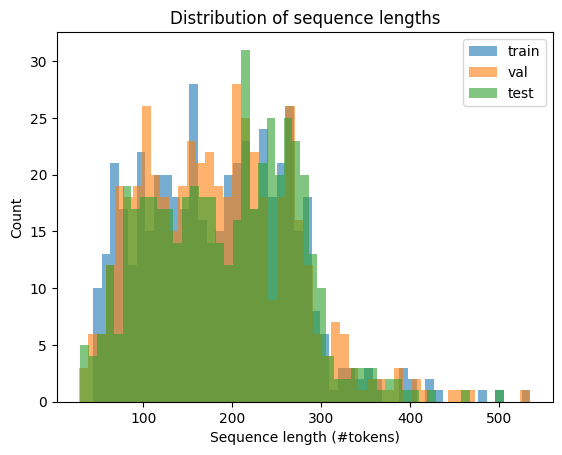

Max lengths:
  Train: 535
  Val  : 533
  Test : 505


In [12]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Load dataset
ds, text_col, label_col, labels = load_ner_dataset("bc5cdr") #bc5cdr

# ---- Sequence lengths ----
train_lengths = [len(x) for x in ds["train"][text_col]]
val_lengths = [len(x) for x in ds["validation"][text_col]]
test_lengths = [len(x) for x in ds["test"][text_col]]

plt.hist(train_lengths, bins=50, alpha=0.6, label="train")
plt.hist(val_lengths, bins=50, alpha=0.6, label="val")
plt.hist(test_lengths, bins=50, alpha=0.6, label="test")
plt.xlabel("Sequence length (#tokens)")
plt.ylabel("Count")
plt.title("Distribution of sequence lengths")
plt.legend()
plt.show()

print("Max lengths:")
print("  Train:", max(train_lengths))
print("  Val  :", max(val_lengths))
print("  Test :", max(test_lengths))




## 3) Visual check: show tokens with BIO labels


Label distribution in train set:
B-Chemical     : 3090
B-Disease      : 1864
I-Chemical     : 2
I-Disease      : 69
O              : 87999


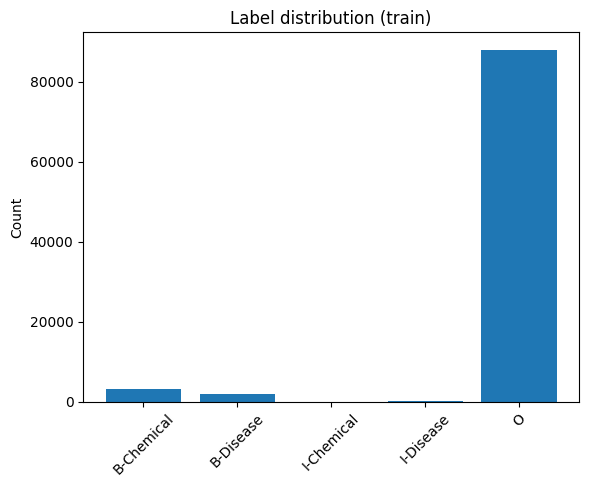

In [10]:
# ---- Label distribution ----
flat_labels = sum(ds["train"][label_col], [])  # flatten list of lists
counts = Counter(flat_labels)

print("\nLabel distribution in train set:")
for i, label_name in enumerate(labels):
    print(f"{label_name:15s}: {counts[i]}")


plt.bar(range(len(labels)), [counts[i] for i in range(len(labels))])
plt.xticks(range(len(labels)), labels, rotation=45)
plt.ylabel("Count")
plt.title("Label distribution (train)")
plt.show()
